# Лабораторна 4 - Багатокласові нейронні мережі

**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 4  
**Тема лабораторної:** Багатокласові нейронні мережі


## Цілі лабораторної

- Реалізувати функції активації ReLU та Softmax із числово стабільними формулами
- Розширити клас `NeuralNetwork` для підтримки довільної кількості шарів
- Реалізувати прямий хід (forward pass) для глибокої мережі з кешуванням проміжних значень
- Реалізувати категоріальну крос-ентропію як узагальнення бінарної втрати
- Реалізувати зворотний прохід (backpropagation) для багатошарової мережі
- Тренувати нейронну мережу на задачах багатокласової класифікації
- Порівняти підхід Softmax зі стратегією «один проти решти» (One-vs-Rest)
- Дослідити вплив глибини мережі на якість класифікації

## Передумови

- Реалізація двошарової бінарної нейронної мережі (Тиждень 3)
- Розуміння функцій активації sigmoid та tanh та їхніх похідних
- Знання зворотного поширення помилки для одного прихованого шару
- Базові знання лінійної алгебри (множення матриць, транспонування)

## Налаштування середовища

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression as SklearnLR

import importlib
import nn_multiclass_student as nn
importlib.reload(nn)

COLORS = ['#4C72B0', '#DD8452', '#55A868']
SEED = 42

---
## 1. - Активаційні функції: ReLU та Softmax

### 1.1 Нові функції активації

На минулому тижні ми реалізували **sigmoid** та **tanh** для двошарової мережі.
Сьогодні додаємо ще дві:

| Функція | Формула | Призначення |
|---------|---------|-------------|
| **ReLU** | $\max(0,\, z)$ | Прихований шар - розріджена, швидка активація |
| **Softmax** | $\displaystyle\sigma(z)_k = \frac{e^{z_k - \max z}}{\sum_j e^{z_j - \max z}}$ | Вихідний шар - перетворює логіти у розподіл імовірностей |

**Числова стабільність Softmax.** Якщо $z_k$ великі, $e^{z_k}$ може переповнити float64.  
Трюк: відняти $\max(z)$ перед потенціюванням - це не змінює результат, але запобігає overflow:
$$\sigma(z)_k = \frac{e^{z_k - \max z}}{\sum_j e^{z_j - \max z}}$$

Реалізуйте `relu`, `relu_derivative` та `softmax` у файлі `nn_multiclass_student.py`.

In [18]:
# ── Test: relu ──────────────────────────────────────────────────────────────
importlib.reload(nn)
z_test = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
r = nn.relu(z_test)
print('relu(z):', r)
assert np.allclose(r, [0, 0, 0, 1, 3]), 'relu values wrong'
assert r.shape == z_test.shape, 'shape mismatch'
print('✓ relu OK')

dr = nn.relu_derivative(z_test)
print('relu_derivative(z):', dr)
assert np.allclose(dr, [0, 0, 0, 1, 1]), 'relu_derivative values wrong'
print('✓ relu_derivative OK')

relu(z): [0. 0. 0. 1. 3.]
✓ relu OK
relu_derivative(z): [0. 0. 0. 1. 1.]
✓ relu_derivative OK


In [19]:
# ── Test: softmax ──────────────────────────────────────────────────────────
importlib.reload(nn)
z_batch = np.array([[1.0, 2.0, 3.0],
                    [0.5, 0.5, 0.5],
                    [10.0, 0.0, 0.0]])   # extreme values - checks numerical stability

s = nn.softmax(z_batch)
print('softmax output (3x3):')
print(np.round(s, 4))
print('row sums:', s.sum(axis=1))

assert s.shape == z_batch.shape, 'shape mismatch'
assert np.allclose(s.sum(axis=1), 1.0), 'rows must sum to 1'
assert (s >= 0).all() and (s <= 1).all(), 'values must be in [0, 1]'
assert not np.any(np.isnan(s)) and not np.any(np.isinf(s)), 'NaN/Inf detected - check numerical stability'
# Uniform input → uniform output
assert np.allclose(s[1], [1/3, 1/3, 1/3], atol=1e-6), 'uniform logits should give uniform probs'
# Largest logit gets highest probability
assert np.argmax(s[0]) == 2, 'argmax should be the largest logit'
print('✓ softmax OK')

softmax output (3x3):
[[0.09   0.2447 0.6652]
 [0.3333 0.3333 0.3333]
 [0.9999 0.     0.    ]]
row sums: [1. 1. 1.]
✓ softmax OK


### 1.2 Візуалізація активаційних функцій

Нижче - порівняння всіх чотирьох функцій активації, що використовуються у нашій мережі.

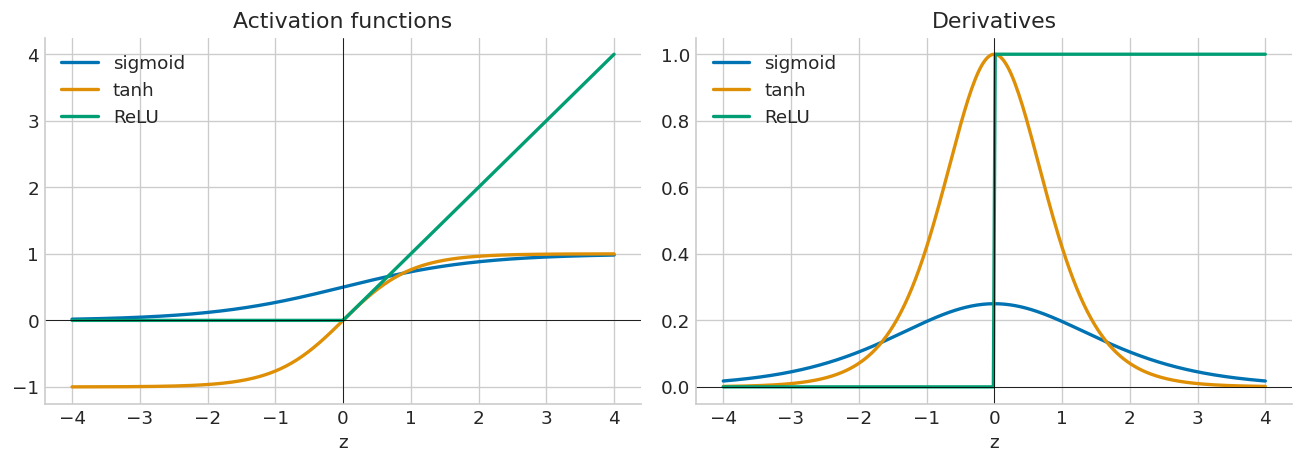

In [20]:
importlib.reload(nn)
z = np.linspace(-4, 4, 300)
z_clipped = np.clip(z, -500, 500)

activations_plot = {
    'sigmoid':  1 / (1 + np.exp(-z_clipped)),
    'tanh':     np.tanh(z),
    'ReLU':     nn.relu(z),
}
derivatives_plot = {
    'sigmoid':  (1 / (1 + np.exp(-z_clipped))) * (1 - 1 / (1 + np.exp(-z_clipped))),
    'tanh':     1 - np.tanh(z) ** 2,
    'ReLU':     nn.relu_derivative(z),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, vals in activations_plot.items():
    axes[0].plot(z, vals, label=name, lw=2)
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_title('Activation functions'); axes[0].legend(); axes[0].set_xlabel('z')

for name, vals in derivatives_plot.items():
    axes[1].plot(z, vals, label=name, lw=2)
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)
axes[1].set_title('Derivatives'); axes[1].legend(); axes[1].set_xlabel('z')

plt.tight_layout()
plt.show()

---
## 2. - Ініціалізація ваг

Клас `NeuralNetwork` підтримує довільну кількість шарів.  
Метод `initialise_params` має заповнити `self.params_` матрицями ваг та зсувів для кожного шару.

Ми використовуємо **Xavier (Glorot) ініціалізацію**:
$$W_l \sim \mathcal{N}\!\left(0,\, \frac{1}{n_{in}}\right), \quad b_l = \mathbf{0}$$
де $n_{in}$ - кількість входів до шару $l$.

Реалізуйте `initialise_params` у класі `NeuralNetwork` файлу `nn_multiclass_student.py`.

In [21]:
importlib.reload(nn)

# Build a 3-layer network: 4 inputs → 8 hidden → 6 hidden → 3 outputs
model_test = nn.NeuralNetwork([4, 8, 6, 3], ['relu', 'relu', 'softmax'])
model_test.initialise_params()

expected = {'W1': (8, 4), 'b1': (8,), 'W2': (6, 8), 'b2': (6,), 'W3': (3, 6), 'b3': (3,)}
print(f"{'Key':<6}  {'Expected shape':<18}  {'Actual shape':<18}  OK?")
print('-' * 55)
for key, exp_shape in expected.items():
    actual = model_test.params_[key].shape
    ok = '✓' if actual == exp_shape else '✗'
    print(f"{key:<6}  {str(exp_shape):<18}  {str(actual):<18}  {ok}")

# Biases must be zero; weights must be non-zero
assert np.allclose(model_test.params_['b1'], 0), 'biases must start at zero'
assert not np.allclose(model_test.params_['W1'], 0), 'weights must not all be zero'
print('\n✓ initialise_params OK')

Key     Expected shape      Actual shape        OK?
-------------------------------------------------------
W1      (8, 4)              (8, 4)              ✓
b1      (8,)                (8,)                ✓
W2      (6, 8)              (6, 8)              ✓
b2      (6,)                (6,)                ✓
W3      (3, 6)              (3, 6)              ✓
b3      (3,)                (3,)                ✓

✓ initialise_params OK


---
## 3. - Прямий хід

Прямий хід для мережі з $L$ шарів:
$$Z_l = A_{l-1}\,W_l^\top + b_l, \qquad A_l = f_l(Z_l), \qquad l = 1, \ldots, L$$
де $A_0 = X$, а $f_l$ - функція активації шару $l$.

Метод `forward` повинен повернути вихідні активації $A_L$ та словник `cache` з усіма проміжними значеннями $Z_l$, $A_l$ - вони знадобляться для зворотнього проходу.

Реалізуйте метод `forward` у класі `NeuralNetwork`.

In [22]:
importlib.reload(nn)

rng = np.random.default_rng(0)
X_dummy = rng.normal(size=(10, 4))   # 10 samples, 4 features

model_fwd = nn.NeuralNetwork([4, 8, 6, 3], ['relu', 'relu', 'softmax'])
model_fwd.initialise_params()

A_out, cache = model_fwd.forward(X_dummy)

print('Output shape:', A_out.shape)         # expect (10, 3)
print('Row sums (should be 1):', A_out.sum(axis=1).round(6))
print('Cache keys:', sorted(cache.keys()))

assert A_out.shape == (10, 3), 'wrong output shape'
assert np.allclose(A_out.sum(axis=1), 1.0), 'softmax rows must sum to 1'
assert (A_out >= 0).all(), 'softmax output must be non-negative'
# Verify all cache entries are present
for key in ['A0', 'Z1', 'A1', 'Z2', 'A2', 'Z3', 'A3']:
    assert key in cache, f'cache missing key {key!r}'
print('✓ forward OK')

Output shape: (10, 3)
Row sums (should be 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Cache keys: ['A0', 'A1', 'A2', 'A3', 'Z1', 'Z2', 'Z3']
✓ forward OK


---
## 4. - Функція втрат: категоріальна крос-ентропія

### 4.1 Від бінарної до категоріальної крос-ентропії

На третьому тижні ми мінімізували **бінарну крос-ентропію** для двох класів:
$$\mathcal{L} = -\frac{1}{N}\sum_i \bigl[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\bigr]$$

Для $K$ класів (one-hot кодування $Y \in \{0,1\}^{N \times K}$) це узагальнюється до **категоріальної крос-ентропії**:
$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{K} Y_{ik}\,\log\hat{P}_{ik}$$
де $\hat{P}_{ik} = \text{softmax}(Z_L)_{ik}$.

Оскільки $Y_{ik}=1$ лише для справжнього класу $k^*_i$, на практиці обчислюють:
$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log\hat{P}_{i,\,k^*_i}$$

Реалізуйте метод `compute_loss` у класі `NeuralNetwork`.

In [23]:
importlib.reload(nn)

# Perfect predictions: class 0 → [1,0,0], class 1 → [0,1,0], class 2 → [0,0,1]
A_perfect = np.array([[0.9999, 0.0001, 0.0000],
                      [0.0000, 0.9999, 0.0001],
                      [0.0001, 0.0000, 0.9999]])
y_perfect = np.array([0, 1, 2])

# Worst case: uniform predictions
A_uniform = np.full((3, 3), 1/3)

model_loss = nn.NeuralNetwork([2, 4, 3], ['relu', 'softmax'])

loss_perfect = model_loss.compute_loss(A_perfect, y_perfect)
loss_uniform = model_loss.compute_loss(A_uniform, y_perfect)

print(f'Loss (perfect predictions): {loss_perfect:.4f}  (should be ≈ 0)')
print(f'Loss (uniform predictions): {loss_uniform:.4f}  (should be ≈ {np.log(3):.4f} = ln(K))')

assert loss_perfect < 0.01, 'perfect predictions should give near-zero loss'
assert abs(loss_uniform - np.log(3)) < 0.01, f'uniform loss should be ln(K)={np.log(3):.4f}'
assert loss_perfect < loss_uniform, 'perfect predictions must have lower loss'
print('✓ compute_loss OK')

Loss (perfect predictions): 0.0001  (should be ≈ 0)
Loss (uniform predictions): 1.0986  (should be ≈ 1.0986 = ln(K))
✓ compute_loss OK


### 4.2 Початкова втрата при випадковій ініціалізації

Для $K$ класів та рівномірно ініціалізованих ваг очікувана початкова втрата $\approx \ln K$.  
Перевіримо це на практиці.

In [24]:
importlib.reload(nn)

for K in [2, 3, 5, 10]:
    rng  = np.random.default_rng(0)
    X_d  = rng.normal(size=(200, 4))
    y_d  = rng.integers(0, K, size=200)
    m    = nn.NeuralNetwork([4, 16, K], ['relu', 'softmax'])
    m.initialise_params()
    A_d, _ = m.forward(X_d)
    loss_d = m.compute_loss(A_d, y_d)
    print(f'  K={K:>2d}  initial loss={loss_d:.4f}   ln(K)={np.log(K):.4f}')

  K= 2  initial loss=0.7305   ln(K)=0.6931
  K= 3  initial loss=1.2125   ln(K)=1.0986
  K= 5  initial loss=1.6613   ln(K)=1.6094
  K=10  initial loss=2.4209   ln(K)=2.3026


---
## 5. - Зворотній хід та перевірка градієнтів

### 5.1 Градієнти

Для вихідного шару з softmax + категоріальна крос-ентропія градієнт $\partial\mathcal{L}/\partial Z_L$ має елегантну форму:
$$\frac{\partial \mathcal{L}}{\partial Z_L} = \frac{1}{N}\bigl(\hat{P} - Y\bigr)$$
де $Y$ - one-hot матриця.

Далі для кожного шару $l = L, L{-}1, \ldots, 1$:
$$\frac{\partial\mathcal{L}}{\partial W_l} = \delta Z_l^\top\, A_{l-1}, \quad
\frac{\partial\mathcal{L}}{\partial b_l} = \sum_i \delta Z_{l,i}, \quad
\delta Z_{l-1} = \delta Z_l\, W_l \odot f'_{l-1}(Z_{l-1})$$

Реалізуйте методи `backward` та `update_params` у класі `NeuralNetwork`.

In [25]:
# ── Numerical gradient check ────────────────────────────────────────────────
importlib.reload(nn)

def numerical_gradient(model, X, y, param_key, eps=1e-5):
    """Estimate dL/dW numerically using the centred difference formula."""
    param = model.params_[param_key]
    grad_numerical = np.zeros_like(param)
    it = np.nditer(param, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        orig = param[idx]
        param[idx] = orig + eps
        A_out_p, _ = model.forward(X)
        loss_p = model.compute_loss(A_out_p, y)
        param[idx] = orig - eps
        A_out_m, _ = model.forward(X)
        loss_m = model.compute_loss(A_out_m, y)
        param[idx] = orig
        grad_numerical[idx] = (loss_p - loss_m) / (2 * eps)
        it.iternext()
    return grad_numerical

rng   = np.random.default_rng(7)
X_gc  = rng.normal(size=(20, 3))
y_gc  = rng.integers(0, 4, size=20)

model_gc = nn.NeuralNetwork([3, 5, 4, 4], ['tanh', 'relu', 'softmax'])
model_gc.initialise_params()

A_gc, cache_gc = model_gc.forward(X_gc)
grads_gc       = model_gc.backward(y_gc, cache_gc)

print(f"{'Parameter':<6}  {'Max abs error':<16}  {'Relative error':<16}  OK?")
print('-' * 55)
all_ok = True
for key in ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']:
    grad_num  = numerical_gradient(model_gc, X_gc, y_gc, key)
    grad_anal = grads_gc[f'd{key}']
    abs_err   = np.abs(grad_num - grad_anal).max()
    rel_err   = abs_err / (np.abs(grad_num).max() + 1e-8)
    ok        = abs_err < 1e-4
    all_ok    = all_ok and ok
    print(f"{key:<6}  {abs_err:<16.2e}  {rel_err:<16.2e}  {'✓' if ok else '✗'}")

print()
print('✓ Gradient check PASSED' if all_ok else '✗ Gradient check FAILED - check backward()')

Parameter  Max abs error     Relative error    OK?
-------------------------------------------------------
W1      2.01e-11          8.28e-10          ✓
b1      1.21e-11          3.08e-10          ✓
W2      1.72e-11          6.43e-10          ✓
b2      1.02e-11          2.15e-10          ✓
W3      2.66e-11          1.16e-09          ✓
b3      1.36e-11          2.84e-10          ✓

✓ Gradient check PASSED


## 6. - Навчання та оцінка

### 6.1 Синтетичні дані: 3 класи

Почнемо з простого тривимірного датасету, що генерується функцією `make_blobs`.

In [26]:
# ── Dataset preparation ─────────────────────────────────────────────────────
X_blobs, y_blobs = make_blobs(n_samples=600, centers=3, cluster_std=1.5,
                               random_state=SEED)

scaler = StandardScaler()
X_blobs = scaler.fit_transform(X_blobs)

X_tr, X_te, y_tr, y_te = train_test_split(X_blobs, y_blobs,
                                            test_size=0.25, random_state=SEED)
print(f'Train: {X_tr.shape}, Test: {X_te.shape}')
print(f'Classes: {np.unique(y_tr)}')

Train: (450, 2), Test: (150, 2)
Classes: [0 1 2]


In [27]:
# ── Train ────────────────────────────────────────────────────────────────────
importlib.reload(nn)

model_blobs = nn.NeuralNetwork(
    layer_sizes=[2, 16, 8, 3],
    activations=['relu', 'relu', 'softmax'],
    random_state=SEED
)
model_blobs.fit(X_tr, y_tr, lr=0.05, n_epochs=1000, verbose=True)

  Epoch     0  loss=1.0985
  Epoch   200  loss=0.0878
  Epoch   400  loss=0.0186
  Epoch   600  loss=0.0090
  Epoch   800  loss=0.0060
  Epoch   999  loss=0.0045


Test accuracy: 1.000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        51
           2       1.00      1.00      1.00        55

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



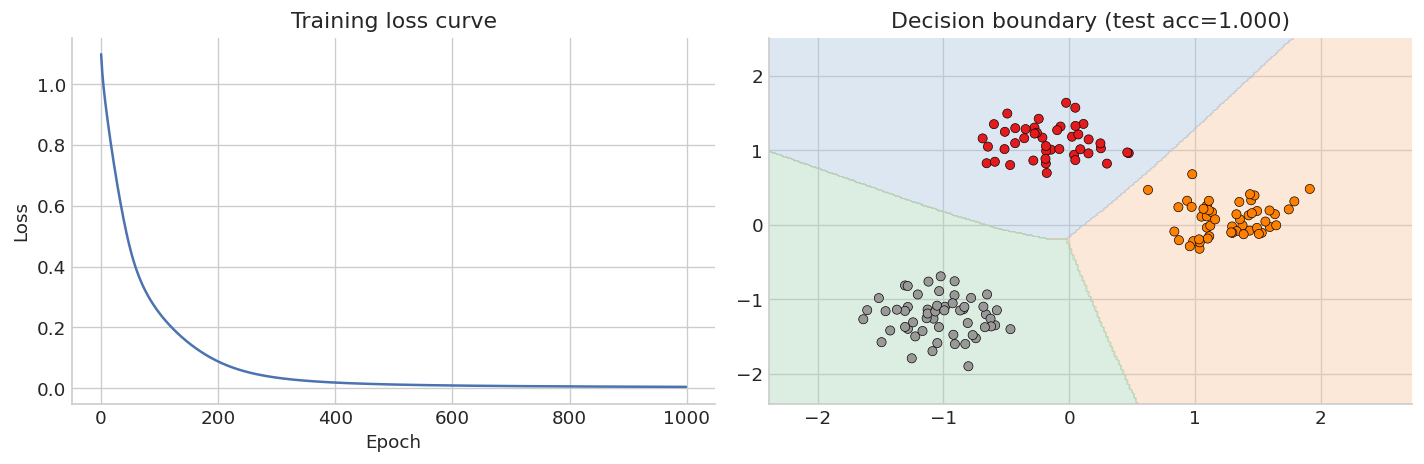

In [28]:
# ── Evaluate & visualise ─────────────────────────────────────────────────────
y_pred = model_blobs.predict(X_te)
acc    = accuracy_score(y_te, y_pred)
print(f'Test accuracy: {acc:.3f}')
print()
print(classification_report(y_te, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(model_blobs.loss_curve_, color='#4C72B0', lw=1.5)
axes[0].set_title('Training loss curve')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

# Decision boundary
cmap3 = ListedColormap(['#A8C4E0', '#F5C6A0', '#A8D5B5'])
x0 = np.linspace(X_blobs[:,0].min()-0.5, X_blobs[:,0].max()+0.5, 300)
x1 = np.linspace(X_blobs[:,1].min()-0.5, X_blobs[:,1].max()+0.5, 300)
xx, yy = np.meshgrid(x0, x1)
Z = model_blobs.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.4, cmap=cmap3)
axes[1].scatter(X_te[:,0], X_te[:,1], c=y_te, cmap='Set1',
                edgecolors='k', s=30, linewidths=0.4)
axes[1].set_title(f'Decision boundary (test acc={acc:.3f})')

plt.tight_layout()
plt.show()

### 6.2 Реальні дані: датасет Iris (4 ознаки, 3 класи)

Iris - класичний датасет машинного навчання з 150 спостереженнями, 4 ознаками та 3 видами квітів.  
Задача не є тривіальною: класи *versicolor* та *virginica* частково перекриваються.

In [29]:
# ── Iris dataset ─────────────────────────────────────────────────────────────
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

scaler_iris = StandardScaler()
X_iris = scaler_iris.fit_transform(X_iris)

X_itr, X_ite, y_itr, y_ite = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=SEED, stratify=y_iris)

print(f'Train: {X_itr.shape}, Test: {X_ite.shape}')
print(f'Class names: {iris.target_names}')

Train: (120, 4), Test: (30, 4)
Class names: ['setosa' 'versicolor' 'virginica']


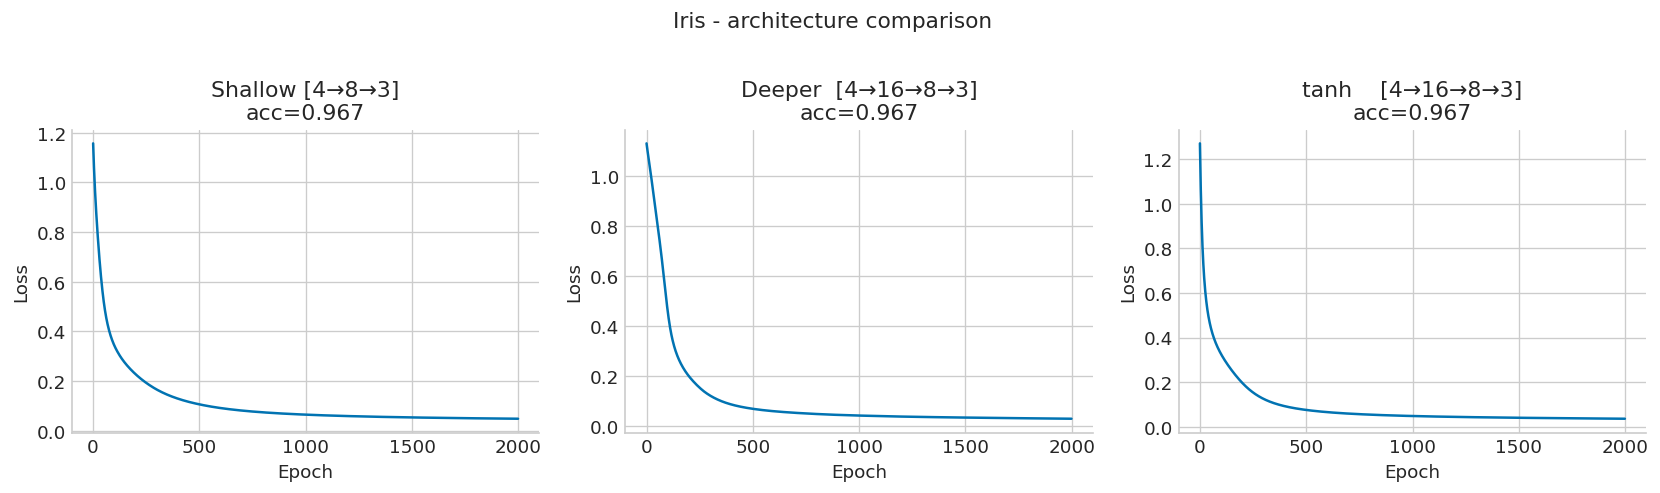

In [30]:
importlib.reload(nn)

# Compare different architectures
architectures = [
    ([4, 8, 3],     ['relu', 'softmax'],          'Shallow [4→8→3]'),
    ([4, 16, 8, 3], ['relu', 'relu', 'softmax'],  'Deeper  [4→16→8→3]'),
    ([4, 16, 8, 3], ['tanh', 'tanh', 'softmax'],  'tanh    [4→16→8→3]'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (sizes, acts, label) in zip(axes, architectures):
    m = nn.NeuralNetwork(sizes, acts, random_state=SEED)
    m.fit(X_itr, y_itr, lr=0.05, n_epochs=2000, verbose=False)
    acc_i = accuracy_score(y_ite, m.predict(X_ite))
    ax.plot(m.loss_curve_, lw=1.5)
    ax.set_title(f'{label}\nacc={acc_i:.3f}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')

plt.suptitle('Iris - architecture comparison', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. - One-vs-Rest проти Softmax

### 7.1 Стратегія One-vs-Rest (OvR)

Один із способів вирішити задачу з $K$ класами - навчити $K$ незалежних бінарних класифікаторів, кожен з яких відповідає на питання *«чи належить зразок до класу $k$?»*.

| | One-vs-Rest | Softmax |
|---|---|---|
| Кількість моделей | $K$ (незалежних) | 1 |
| Функція виходу | $K$ сигмоїд | 1 softmax |
| Нормалізація ймовірностей | ❌ (не гарантована) | ✅ (сума = 1) |
| Врахування взаємовиключності класів | ❌ | ✅ |

Нижче порівняємо OvR на основі логістичної регресії та нашу softmax мережу.

In [31]:
importlib.reload(nn)

# ── Softmax Neural Network ───────────────────────────────────────────────────
model_softmax = nn.NeuralNetwork([4, 16, 8, 3], ['relu', 'relu', 'softmax'],
                                  random_state=SEED)
model_softmax.fit(X_itr, y_itr, lr=0.05, n_epochs=2000, verbose=False)
acc_softmax = accuracy_score(y_ite, model_softmax.predict(X_ite))

# ── One-vs-Rest Logistic Regression ─────────────────────────────────────────
ovr = OneVsRestClassifier(SklearnLR(max_iter=1000, random_state=SEED))
ovr.fit(X_itr, y_itr)
acc_ovr = accuracy_score(y_ite, ovr.predict(X_ite))

# ── sklearn MLP (reference) ──────────────────────────────────────────────────
mlp_ref = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu',
                        max_iter=2000, random_state=SEED)
mlp_ref.fit(X_itr, y_itr)
acc_mlp = accuracy_score(y_ite, mlp_ref.predict(X_ite))

print(f'Softmax NN (our impl):      {acc_softmax:.3f}')
print(f'One-vs-Rest LogReg:         {acc_ovr:.3f}')
print(f'sklearn MLP (reference):    {acc_mlp:.3f}')

Softmax NN (our impl):      0.967
One-vs-Rest LogReg:         0.900
sklearn MLP (reference):    0.967


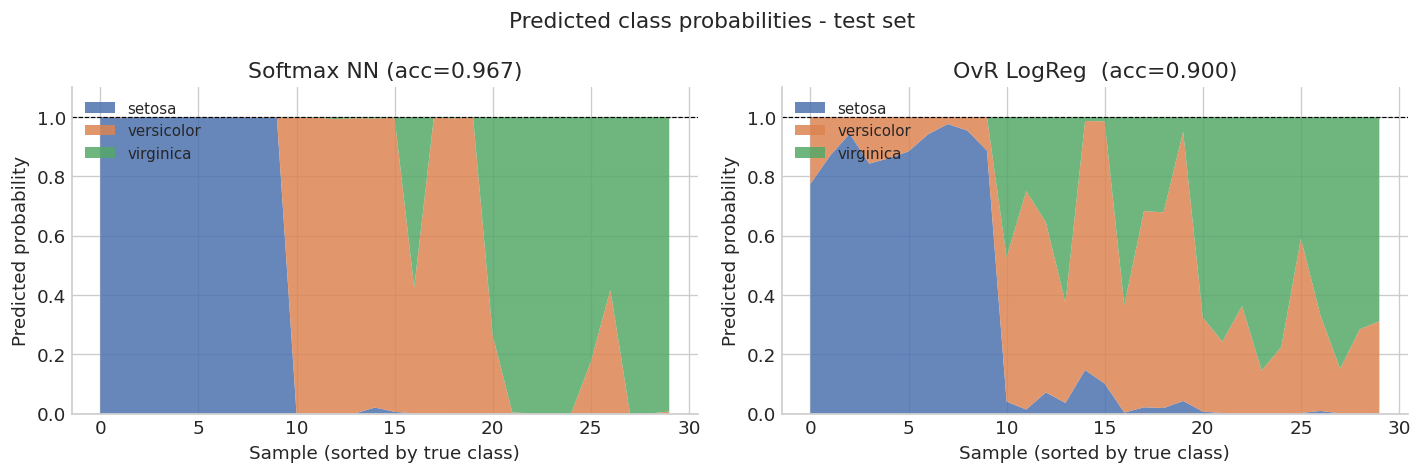


Softmax row sums (should all be 1.0): min=1.000000, max=1.000000
OvR row sums (not guaranteed 1.0):   min=1.000000, max=1.000000


In [32]:
# ── Visualise predicted probabilities ───────────────────────────────────────
proba_softmax = model_softmax.predict_proba(X_ite)          # (N, 3), sums to 1
proba_ovr     = ovr.predict_proba(X_ite)                   # (N, 3), may not sum to 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (proba, title) in zip(axes, [
        (proba_softmax, f'Softmax NN (acc={acc_softmax:.3f})'),
        (proba_ovr,     f'OvR LogReg  (acc={acc_ovr:.3f})'),
    ]):
    sorted_idx = np.argsort(y_ite)
    p = proba[sorted_idx]
    ax.stackplot(range(len(p)), p[:, 0], p[:, 1], p[:, 2],
                 labels=iris.target_names, alpha=0.85,
                 colors=['#4C72B0', '#DD8452', '#55A868'])
    ax.axhline(1.0, color='k', lw=0.7, ls='--')
    ax.set_ylim(0, 1.1); ax.set_title(title)
    ax.set_xlabel('Sample (sorted by true class)')
    ax.set_ylabel('Predicted probability')
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Predicted class probabilities - test set', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nSoftmax row sums (should all be 1.0): min={proba_softmax.sum(1).min():.6f}, max={proba_softmax.sum(1).max():.6f}')
print(f'OvR row sums (not guaranteed 1.0):   min={proba_ovr.sum(1).min():.6f}, max={proba_ovr.sum(1).max():.6f}')

---
## Підсумок

| Тема | Ключовий висновок |
|------|-------------------|
| **ReLU** | Проста та ефективна активація для прихованих шарів; похідна - ступінчаста функція |
| **Softmax** | Перетворює логіти у нормалізований розподіл імовірностей; числова стабільність через log-sum-exp trick |
| **Категоріальна крос-ентропія** | Узагальнення бінарної крос-ентропії для $K$ класів; при рівномірних передбаченнях $\mathcal{L} \approx \ln K$ |
| **Зворотній прохід (узагальнений)** | Один цикл по шарах; combined softmax + CE градієнт $(\hat{P} - Y)/N$ - елегантний і ефективний |
| **Softmax vs OvR** | Softmax моделює взаємовиключність класів явно; OvR - навчає $K$ незалежних бінарних моделей |
| **Глибина мережі** | Глибші мережі можуть краще апроксимувати складні межі, але потребують ретельного вибору гіперпараметрів |
